# Praktikum SW6 (P5) Lineare Ausgleichsrechnung mit QR-Zerlegung

Im ersten Teil des Praktikums soll die QR-Zerlegung implementiert werden. 

1. Implementieren Sie die QR-Zerlegung und den entsprechenden Least-Squares Algorithmus  
  1.1 Implementieren Sie eine einzelne Householder-Transformation  
  1.2 Implementieren Sie die QR-Zerlegung mit Hilfe der Householder-Transformation  
  1.3 Erstellen Sie eine Funktion, die lineare Ausgleichsprobleme mittels QR-Zerlegung löst

Im zweiten Teil wenden Sie die QR-Zerlegung auf ein lineares Ausgleichsproblem an. 

In [315]:
import numpy as np
import matplotlib.pyplot as plt

### Aufgabe 1: QR-Zerlegung einer Matrix A
Die **QR-Zerlegung** einer Matrix $A \in \mathbb{R}^{N \times n}$ ist eine Zerlegung
$$
    A = Q R, \qquad Q \in \mathbb{R}^{N \times N}, \,\,\, R \in \mathbb{R}^{N \times n}
$$

mit einer *orthogonalen* Matrix $Q$ und einer Matrix $R$ in Zeilenstufenform. Nur die ersten $n$ Zeilen von $R$ enthalten Einträge, die von $0$ verschieden sind.

$Q$ wird als Zusammensetzung von $n$ Householder-Spiegelungen konstruiert:

$$
    Q^T = H_n \cdot H_{n-1} \cdot \ldots \cdot H_1
$$

### 1.1 Einzelne Householder-Spiegelung

Erstellen Sie eine Funktion, die die Householder-Spiegelung $H$ zu einem gegebenen Vektor $\vec{a}$ erstellt, d.h. es gilt

$$
        H\, \vec{a} = |\vec{a}| \cdot \vec{e}_1 = \Big( |\vec{a}|, 0, \ldots,0 \Big)
$$

und $H$ ist eine orthogonale Matrix.

In [316]:
# Berechnung einer Householder-Spiegelung
def householder(a): 
    n = a.copy() 
    n[0] += np.linalg.norm(a)
    #normieren:
    n = n / np.linalg.norm(n)
    E = np.eye(a.size)


    H = E - (2*np.outer(n,n))
    return H

Hier können Sie testen, ob das funktioniert. 

In [317]:
dim = 5 
a = np.random.randn(dim)
H = householder(a)
b = H @ a
print("ursprünglicher Vektor: ", a)
print("gespiegelter Vektor:   ", b)

assert(np.linalg.norm(b[1:]) < 1e-10) # das sollte = 0 sein, bis auf Rundungsfehler
assert(np.linalg.norm(H.T@H - np.eye(dim)) < 1e-10) # H soll orthogonal sein, d.h. H.T @ H = E

ursprünglicher Vektor:  [ 0.11938657  0.34694176  0.99386232 -0.55336517 -1.75574304]
gespiegelter Vektor:    [-2.12396579e+00 -6.28272222e-17  1.01721613e-17 -1.02516867e-17
  1.80621282e-16]


### 1.2 QR - Zerlegung aus den Householder Transformationen 
Für die QR-Zerlegung einer Matrix $A \in \mathbb{R}^{N \times n}$ müssen $n$ Householder Transformationen hintereinander ausgeführt werden. Im folgenden der Algorithmus in Pseudocode. Achtung: Indices beginnen hier bei 1 im Code aber bei 0. Die Matrix A sollte kopiert werden, falls die ursprüngliche Matrix A noch verfügbar sein soll

* Initialisiere $H = E$ und $R = A$
* Für $k = 1, 2, \ldots, n$
  *   Erstelle die Householder-Transformation $\tilde{H}_k$ zum Vektor $\vec{a} = (r[k,k], ..., r[N,k])$
  *   Erstelle $H_k$ durch Einbettung von $\tilde{H}_k$ in die rechte untere Ecke der $N \times N$ Einheitsmatrix
  *   Setze $H = H_k \cdot H$ und $R = H_k \cdot R$

Am Ende dieses Prozesses ist die erhaltene Matrix $H = Q^T$ und $R = R$.

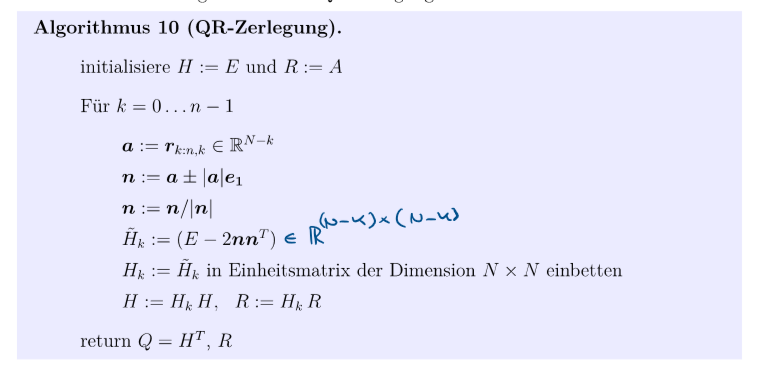

In [318]:
def QR(A):
    R = A.copy()
    N, n = R.shape
    H = np.eye(N)
    for k in range(n):
        a = R[k:,k]
        Hkschlange = householder(a)
        Hk = np.eye(N)        
        Hk [k:,k:] = Hkschlange
        H = Hk @ H
        R = Hk @ R
    return H.T, R

In [319]:
N = 10
n = 3
A = np.random.rand( N, n ) # zufällige N x n Matrix
Q, R = QR(A)

# die folgenden drei Werte müssten alle = 0 sein, bis auf Rundungsfehler
print (np.linalg.norm(Q@R - A) )             # Teste Q R = A
print (np.linalg.norm(Q.T@Q - np.eye(N)))    # Teste Q^T Q = E, also Q ist orthogonal
print(np.linalg.norm(np.tril(R, -1)))        # Teste R ist obere Dreiecksmatrix

2.0647210502368085e-15
1.402905154405658e-15
3.3828471175404173e-16


## 1.3 Lineare Ausgleichsprobleme mit QR-Zerlegung
Erstellen Sie eine Funktion, die als Eingabe eine $N \times n$ Matrix $A$ und einen Vektor $b \in \mathbb{R}^N$ 
akzeptiert und als Ergebnis den Vektor $\vec{p} \in \mathbb{R}^n$ zurückgibt, der das Minimierungsproblem

$$
    |A \vec{p} - \vec{b}|^2 \to \textrm{min}
$$

löst. Wegen $A = Q R$ mit der orthogonalen Matrix $Q$ ist dies gleichwertig zu

$$
    |R \, \vec{p} - Q^T \, \vec{b}|^2 \to \textrm{min}
$$

Da $R$ eine obere Dreiecksmatrix ist, besteht die Lösung darin, die ersten $n$ Gleichungen des LGS

$$
    R \, \vec{p} = Q^T \, \vec{b}
$$

durch Rückwärtseinsetzen zu lösen und die übrigen $N - n$ Gleichungen zu ignorieren.

In [320]:
# Rückwärtseinsetzen, s. P2 mit kleineren Modifikationen für eine N x n Matrix R
def backsub(R, y):
    n = R.shape[1] # Anzahl Spalten von R
    x = np.zeros(n)
    x[-1] = y[-1] / R[n-1, -1]
    for i in range(n-1, -1, -1):
        x[i] = (y[i] - R[i,i+1:] @ x[i+1:]) / R[i, i]

    # Die Toleranz ist hier etwas gross, weil die Matrix in Teil 2 schlecht konditioniert ist, solange nicht skaliert wird
    assert( np.linalg.norm(R[:n,:]@x - y[:n]) < 1e-6) # Test, dass Rückwärtseinsetzen richtig funktioniert

    return x

def lstsq(A, b):
    Q, R = QR(A)
    return backsub(R, Q.T@b)


Hier ist ein kleiner Testcase für die Anwendung "Punkte auf einer Parabel"

gefundene Parameter:  [ 0.67202102  3.06713834 -2.01982847]


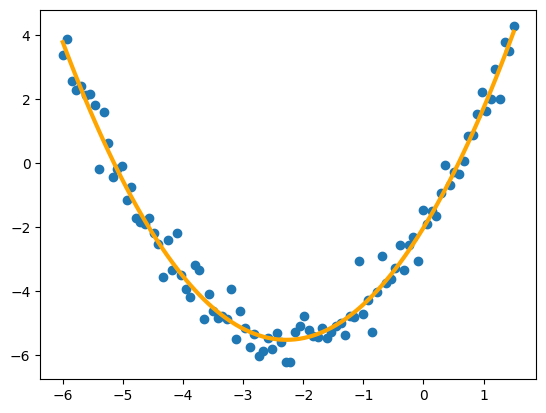

In [321]:
N = 100                    # Anzahl Punkte
a, b, c = 0.65, 3, -2      # Parabel  y = a x^2 + b x + c

xi = np.linspace(-6,1.5,N) 
yi = a * xi**2 + b * xi + c + .5 * np.random.randn(xi.shape[0])

A = np.array([xi**2, xi, np.ones_like(xi)]).T
p = lstsq(A, yi)

print("gefundene Parameter: ", p)

plt.scatter(xi, yi)
plt.plot(xi, A@p, color = "orange", linewidth = 3);


## Zweiter Teil: Anwendung 
Sie bestimmen die Parameter 

$$
    \vec{p} = (p_0, p_1, p_2, p_3, p_4)
$$

des Modells

$$
    y = p_0 + p_1 \cdot \omega + p_2 \cdot \omega^2 + p_3 \cdot \omega^3 + p_4 \cdot s(\omega)
$$

mit 

$$
    s(\omega) = \frac{1}{1 + 4 \cdot \left( \frac{\omega - \omega_0}{s_0} \right)^2}, \qquad \omega_0 = 80300, \, \, s_0 = 100
$$

für die Daten im File "data.txt". 

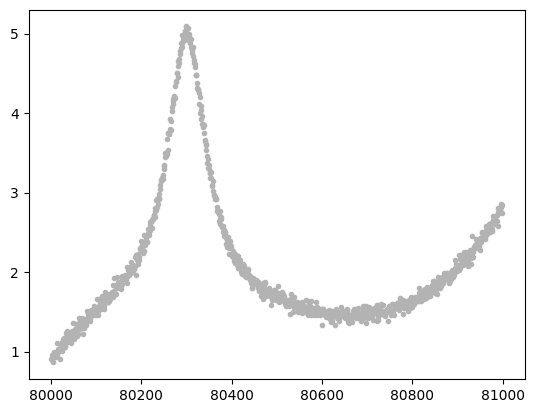

In [322]:
data = np.genfromtxt("NUM1_Praktikum_W6_data.txt")
w, y = data.T

plt.plot(w, y, '.', color = [.7,.7,.7]);

Die Funktion $s$ beschreibt den "Peak", das kubische Polynom ist ein Messartifakt, die sogenannte "Baseline". 

Im vorliegenden Fall sind die Lage $\omega_0$ sowie die Breite $s_0$ des Peaks bekannt. Den realistischeren Fall, wo diese Parameter ebenfalls bestimmt werden müssen behandeln wir später im Rahmen der nichtlinearen Ausgleichsrechnung.

**Bemerkung**: Die Frequenzachse $\omega$ enthält Werte zwischen $80'000$ Hz und $81'000$ Hz. Aus numerischen Gründen ist es sinnvoll, die $\omega$-Achse zu skalieren. Natürlich müssen $\omega_0$ und $s_0$ ebenfalls skaliert werden.

Es ist instruktiv zu sehen, wie die verschiedenen Verfahren  
* QR-Zerlegung
* Normalgleichungen
* numpy lstsq

mit der (ohne Skalierung) schlecht konditionierten Matrix $A$ zurecht kommen oder eben nicht zurecht kommen.

Aus Gründen der Übersichtlichkeit kann die Peak-Funktion als eigene Funktion definiert werden. 

In [323]:
# Skalierung von w, w0, s0 auf Werte zwischen 0 und 1
def scale(w, w0, s0):
    w0s = (w0 - w[0]) / (w[-1] - w[0])
    ws  = (w - w[0]) / (w[-1] - w[0])
    s0s = s0 / (w[-1] - w[0])           # Breite des Peaks, braucht keine Verschiebung
    return ws, w0s, s0s

# Hilfsfunktion "Peak"
s = lambda w, w0, s0: s0**2 / (s0**2 + 4 * (w - w0)**2 )

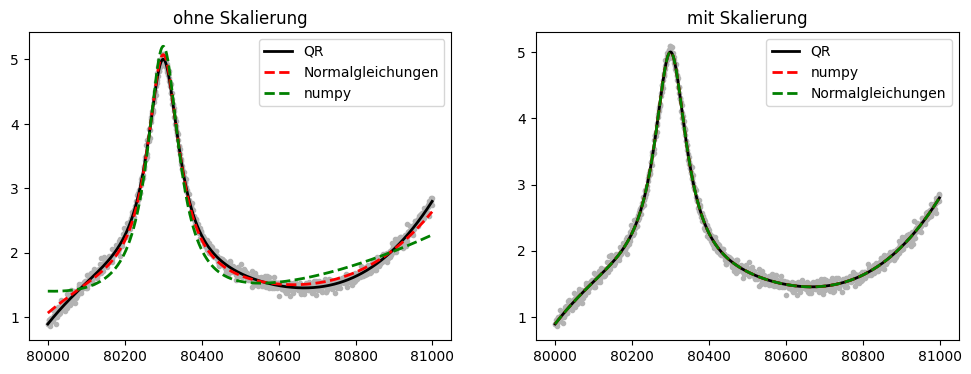

In [324]:
data = np.genfromtxt("NUM1_Praktikum_W6_data.txt")
w, y = data.T

# Zusatzangaben über den Peak
w0 = 80300
s0 = 100

# ohne Skalierung 
###MATRIX FüLLEN: mit 1ern, danach w und w hoch xx werten

A = np.zeros((w.size, 5)) # matrix erstellen, 
A[:,0] = 1 ## das sind die 1 in der ersten spalte
A[:, 1] = w
A[:, 2] = w**2
A[:, 3] = w**3
A[:, 4] = s(w,w0,s0)

p = lstsq(A, y)
pNP,_,_,_ = np.linalg.lstsq(A, y, rcond = -1) # numpy Befehl. Ohne Skalierung funktionert das nicht.
pNE = np.linalg.solve(A.T@A, A.T@y)             # mit den Normalgleichungen

# w Achse skalieren
ws, w0s, s0s = scale(w, w0, s0)


# wie oben, aber mit ws anstelle von w
###MATRIX FüLLEN: mit 1ern, danach w und w hoch xx werten
As = np.zeros((w.size, 5)) # matrix erstellen, 
As[:,0] = 1 ## das sind die 1 in der ersten spalte
As[:, 1] = ws
As[:, 2] = ws**2
As[:, 3] = ws**3
As[:, 4] = s(ws,w0s,s0s)

ps = lstsq(As, y)
psNP,_,_,_ = np.linalg.lstsq(As, y, rcond = None) # numpy Befehl
psNE = np.linalg.solve(As.T@As, As.T@y)             # mit den Normalgleichungen

# plots
fig, ax = plt.subplots(1, 2, figsize = (12, 4)) # zwei plots nebeneinander
ax[0].plot(w, y, '.', color = [.7,.7,.7]);
ax[0].plot(w, A@p, color = "k", linewidth = 2, label = "QR")
ax[0].plot(w, A@pNE, "r--", linewidth = 2, label = "Normalgleichungen")
ax[0].plot(w, A@pNP, "g--", linewidth = 2, label = "numpy")
ax[0].set_title("ohne Skalierung")
ax[0].legend()

ax[1].plot(w, y, '.', color = [.7,.7,.7]);
ax[1].plot(w, As@ps, color = "k", linewidth = 2, label = "QR") # für diese plots muss nichts "zurückskaliert" werden.
ax[1].plot(w, As@psNP, "r--", linewidth = 2, label = "numpy")
ax[1].plot(w, As@psNE, "g--", linewidth = 2, label = "Normalgleichungen")
ax[1].set_title("mit Skalierung")
ax[1].legend()